In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
df = pd.read_csv('baggage.csv',index_col='Date',parse_dates=True)
df.head()

,Airline,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
Date,,,,,,,
2004-01-01,American Eagle,1,2004,12502,38276,2481,992360
2004-02-01,American Eagle,2,2004,8977,35762,886,1060618
2004-03-01,American Eagle,3,2004,10289,39445,1346,1227469
2004-04-01,American Eagle,4,2004,8095,38982,755,1234451
2004-05-01,American Eagle,5,2004,10618,40422,2206,1267581


In [63]:
df['Airline'].value_counts()

American Eagle    84
Hawaiian          84
United            84
Name: Airline, dtype: int64

In [64]:
grouped = df.groupby(df.Airline)
dfAmerican = grouped.get_group("American Eagle")
dfAmerican.head()

,Airline,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
Date,,,,,,,
2004-01-01,American Eagle,1,2004,12502,38276,2481,992360
2004-02-01,American Eagle,2,2004,8977,35762,886,1060618
2004-03-01,American Eagle,3,2004,10289,39445,1346,1227469
2004-04-01,American Eagle,4,2004,8095,38982,755,1234451
2004-05-01,American Eagle,5,2004,10618,40422,2206,1267581


In [65]:
grouped = df.groupby(df.Airline)
dfHawaiian = grouped.get_group("Hawaiian")
dfHawaiian.head()

,Airline,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
Date,,,,,,,
2004-01-01,Hawaiian,1,2004,1717,3879,28,461353
2004-02-01,Hawaiian,2,2004,1599,3743,34,446091
2004-03-01,Hawaiian,3,2004,1327,4052,16,501722
2004-04-01,Hawaiian,4,2004,1350,3918,8,466457
2004-05-01,Hawaiian,5,2004,1304,3976,8,460080


In [66]:
grouped = df.groupby(df.Airline)
dfUnited = grouped.get_group("United")
dfUnited.head()

,Airline,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
Date,,,,,,,
2004-01-01,United,1,2004,25015,45809,1017,4434315
2004-02-01,United,2,2004,16660,42675,312,4458657
2004-03-01,United,3,2004,19318,46512,321,5302929
2004-04-01,United,4,2004,15638,45309,162,5288871
2004-05-01,United,5,2004,19302,46630,652,5408451


<AxesSubplot:xlabel='Date'>

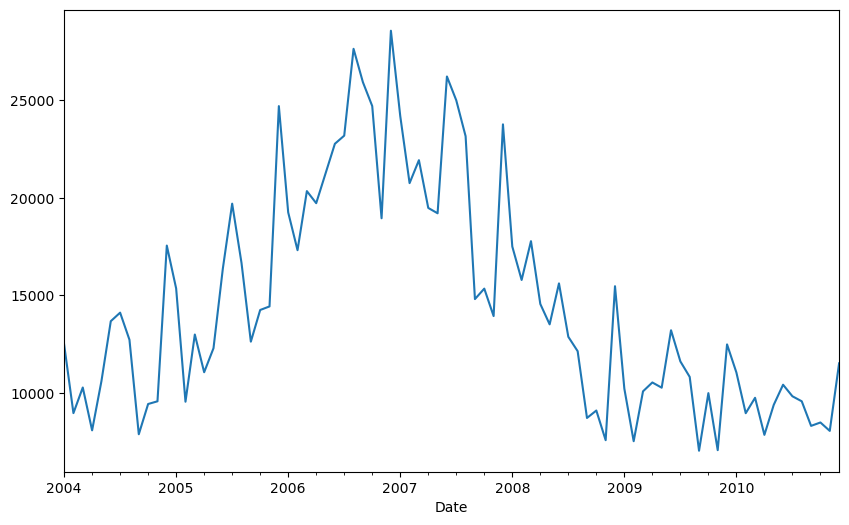

In [67]:
dfAmerican['Baggage'].plot(figsize=(10,6))

In [68]:
fig = px.line(df, y="Baggage", color="Airline", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(plot_bgcolor='white')
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title=''
)
fig.show()

In [69]:
import pmdarima as pm

In [70]:
dfAmerican.index.freq = 'MS'
dfHawaiian.index.freq = 'MS'
dfUnited.index.freq = 'MS'

In [71]:
Ntest = 12
train = dfAmerican.iloc[:-Ntest]
test = dfAmerican.iloc[-Ntest:]

In [72]:
train_idx = dfAmerican.index <= train.index[-1]
test_idx = dfAmerican.index > train.index[-1]

In [73]:
model = pm.auto_arima(train['Baggage'],
                     trace=True,
                     suppress_warnings=True,
                     seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1348.549, Time=0.59 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1452.539, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1373.140, Time=0.07 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1388.515, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1604.574, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1371.513, Time=0.24 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=1364.606, Time=1.20 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=1389.316, Time=0.08 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=1356.277, Time=0.65 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=1365.467, Time=1.22 sec
 ARIMA(1,0,2)(1,0,1)[12] intercept   : AIC=1351.320, Time=0.45 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept

In [74]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   72
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -661.393
Date:                            Sat, 14 Oct 2023   AIC                           1332.786
Time:                                    12:19:08   BIC                           1344.170
Sample:                                01-01-2004   HQIC                          1337.318
                                     - 12-01-2009                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9512      0.033     28.569      0.000       0.886       1.016
ma.L1         -0.0197      0.126     -0.157      0.875      -0.266       0.226
ar.S.L12       0.9975      0.007    144.592      0.000       0.984       1.011
ma.S.L12      -0.8759      0.171     -5.123      0.000      -1.211      -0.541
sigma2      3.608e+06   5.24e-08   6.88e+13      0.000    3.61e+06    3.61e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.79
Prob(Q):                              0.96   Prob(JB):                         0.06
Heteroskedasticity (H):               0.79   Skew:                             0.47
Prob(H) (two-sided):                  0.56   Kurtosis:                         4.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.65e+29. Standard errors may be unstable.
"""

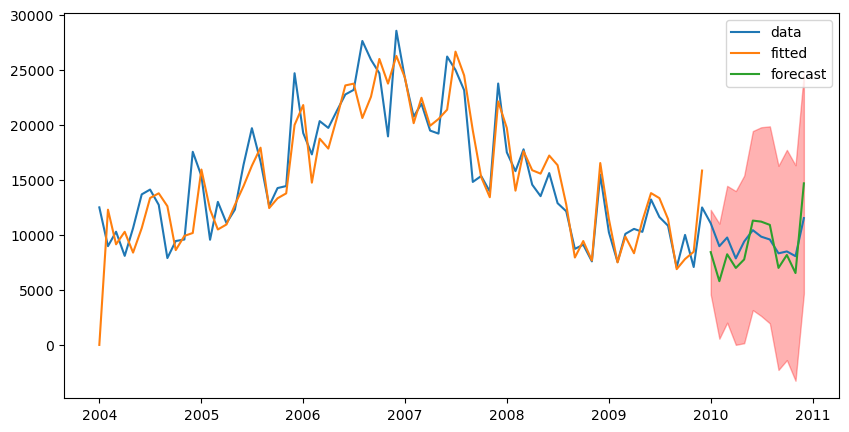

In [75]:
train_pred = model.predict_in_sample(start=0, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dfAmerican.index, dfAmerican['Baggage'], label='data')
ax.plot(train.index, train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1],
               color='red', alpha=0.3)
ax.legend();

In [76]:
from sklearn.metrics import r2_score

In [77]:
print(r2_score(test['Baggage'], test_pred))

-1.7596140967335825


In [78]:
r2_score(train['Baggage'] , train_pred)

0.7621513432866815

In [79]:
r2_score(test['Baggage'] , test_pred)

-1.7596140967335825

In [80]:
print("ESM TEST RMSE:", rmse(test['Baggage'], test_pred))

ESM TEST RMSE: 1854.8152273773737


# ESM

In [81]:
Ntest = 12
train = dfAmerican.iloc[:-Ntest]
test = dfAmerican.iloc[-Ntest:]

In [82]:
train_idx = dfAmerican.index <= train.index[-1]
test_idx = dfAmerican.index > train.index[-1]

In [83]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [84]:
train['Baggage']

Date
2004-01-01    12502
2004-02-01     8977
2004-03-01    10289
2004-04-01     8095
2004-05-01    10618
              ...  
2009-08-01    10832
2009-09-01     7052
2009-10-01    10000
2009-11-01     7081
2009-12-01    12496
Freq: MS, Name: Baggage, Length: 72, dtype: int64

In [85]:
hw = ExponentialSmoothing(
    train['Baggage'],
    initialization_method='heuristic',
    trend=None, seasonal='mul', seasonal_periods=12)
res_hw = hw.fit()

C:\Users\pc\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning:

Optimization failed to converge. Check mle_retvals.



In [86]:
dfAmerican.loc[train_idx, 'HoltWinterTrain'] = res_hw.fittedvalues

C:\Users\pc\AppData\Local\Temp\ipykernel_9412\794948485.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [87]:
dfAmerican.loc[test_idx, 'HoltWinterTest'] = res_hw.forecast(Ntest)

C:\Users\pc\AppData\Local\Temp\ipykernel_9412\1342710399.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



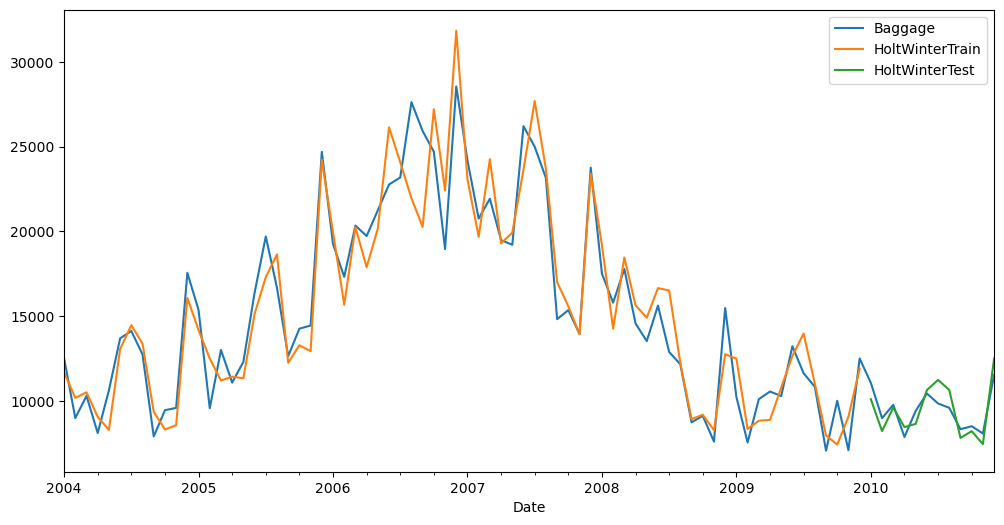

In [88]:
dfAmerican[['Baggage','HoltWinterTrain','HoltWinterTest']].plot(figsize=(12,6));

In [89]:
def rmse(t, y):
    return np.sqrt(np.mean((t - y)**2))

In [90]:
print("ESM TEST RMSE:", rmse(test['Baggage'], res_hw.forecast(Ntest)))

ESM TEST RMSE: 776.0106458267229


In [91]:
r2_score(test['Baggage'] , res_hw.forecast(Ntest))

0.5169607649252133

# FB PROPHET


In [92]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [93]:
dfAmerican.head()

,Airline,Month,Year,Baggage,Scheduled,Cancelled,Enplaned,HoltWinterTrain,HoltWinterTest
Date,,,,,,,,,
2004-01-01,American Eagle,1,2004,12502,38276,2481,992360,11675.301272,NaN
2004-02-01,American Eagle,2,2004,8977,35762,886,1060618,10169.703134,NaN
2004-03-01,American Eagle,3,2004,10289,39445,1346,1227469,10505.163638,NaN
2004-04-01,American Eagle,4,2004,8095,38982,755,1234451,9048.335347,NaN
2004-05-01,American Eagle,5,2004,10618,40422,2206,1267581,8284.595002,NaN


In [94]:
data = dfAmerican['Baggage'].copy()

In [95]:
data.head()

Date
2004-01-01    12502
2004-02-01     8977
2004-03-01    10289
2004-04-01     8095
2004-05-01    10618
Freq: MS, Name: Baggage, dtype: int64

In [96]:
data = data.to_frame()

In [97]:
data.head()

,Baggage
Date,
2004-01-01,12502
2004-02-01,8977
2004-03-01,10289
2004-04-01,8095
2004-05-01,10618


In [100]:
data.shape

(84, 1)

In [101]:
data.tail()

,y
Date,
2010-08-01,9583
2010-09-01,8324
2010-10-01,8498
2010-11-01,8067
2010-12-01,11526


In [102]:
data.columns = ['y']
data['ds'] = data.index

In [112]:
m = Prophet(seasonality_mode='additive')
m.fit(data)

12:29:34 - cmdstanpy - INFO - Chain [1] start processing
12:29:35 - cmdstanpy - INFO - Chain [1] done processing


In [113]:
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)

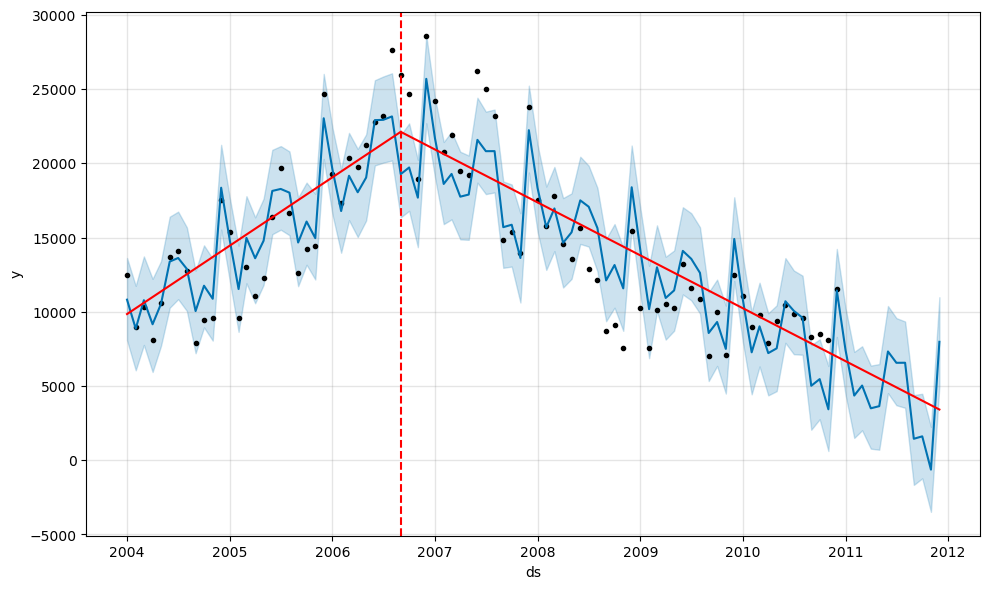

In [111]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)